# Implied volatility evaluation
## Numerical processing of financial data 

Stefano De Marco

#### Objective
The goal of this notebook is to implement some numerical methods that evaluate the implied volatility of a put option from the knowledge of its price.

In [1]:
import numpy as np
import scipy.stats as sps

## Numerical evaluation of the implied volatility of an option

$\blacktriangleright$ As a start, we need the Black-Scholes formula for a put option price.

Recall (once again) that 
$$
\mathrm{Put}^{\mathrm{BS}}_t(T,K,\sigma) = K e^{-r \, (T-t)} N(-d_2) - S \, N(-d_1),
$$

where $d_1 = \frac 1{\sigma \sqrt{T-t}} \log \frac{S \,e^{r(T-t)}}K + \frac 12 \sigma \sqrt{T-t}, \ d_2 = d_1 - \sigma \sqrt{T-t}$, $S$ denotes the underlying asset value at time $t$, and $N(x) = \int_{-\infty}^x \frac 1{\sqrt{2 \pi}} e^{-\frac{y^2} 2} dy$ is the Gaussian cdf.

In [2]:
def Put_BS_core(tau, K, DF, F, sigma):
    """
    Black-Scholes put option price in terms of 
    
    tau   : time to maturity, tau = T - t
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} if constant interest rate r
    F     : underlying forward price
    sigma : volatility
    """
    sigma_sqrt_tau = sigma * np.sqrt(tau)

    d_1 = np.log(F/K)/sigma_sqrt_tau + sigma_sqrt_tau/2.
    d_2 = d_1 - sigma_sqrt_tau

    # Done.
    put_price = DF * (K * sps.norm.cdf(-d_2) - F * sps.norm.cdf(-d_1))

    return put_price

def Put_BS(t, S, T, K, r, sigma):
    """
    Black-Scholes put option price in terms of the standard BS parameters.
    """
    tau = T - t
    
    # Done.
    DF = np.exp(-r*tau)
    F = S * np.exp(r*tau)
    
    return Put_BS_core(tau, K, DF, F, sigma)


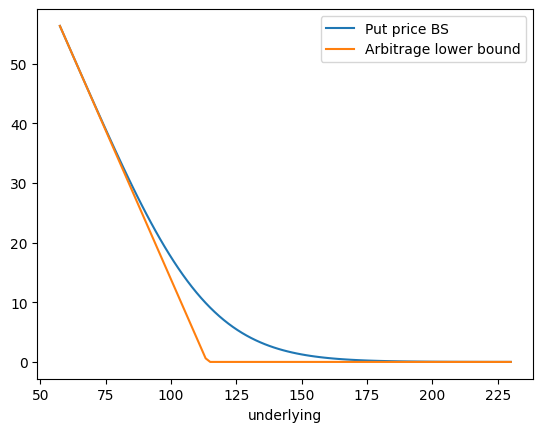

In [3]:
####################
## A numerical check
####################
T = 0.5
K = 115
t = 0
sigma = 0.3
r = 0.02
S = np.linspace(K/2, K*2, 100)

tau = T - t
DF = np.exp(-r*tau)
F = S * np.exp(r*tau)

put_price = Put_BS_core(tau, K, DF, F, sigma)

lower_bound = np.maximum(DF*(K - F), 0)

import matplotlib.pyplot as plt

plt.plot(S , put_price, label="Put price BS")
plt.plot(S , lower_bound, label="Arbitrage lower bound")
plt.xlabel("underlying")
plt.legend(loc="best")
plt.show()

### 1. Newton's method

$\blacktriangleright$ In order to apply Newton's method to the evaluation of the implied volatility, we need to code the expression for the put option vega. Recall that

$$
\mathrm{Vega}_t(t, T, \sigma) = \partial_\sigma \mathrm{Put}^{\mathrm{BS}}_t(T,K,\sigma)
= S \sqrt{T-t} \, n(d_1),
$$
where $n(x) = \frac 1{\sqrt{2 \pi}} e^{-\frac{x^2}2}$.

In [4]:
def Vega_core(tau, K, DF, F, sigma):
    """
    Vega of a Black-Scholes put in terms of
    
    tau   : time to maturity
    K     : strike
    DF    : discount factor
    F     : underlying forward price
    sigma : volatility
    """
    sigma_sqrt_tau = sigma * np.sqrt(tau)
    
    d_1 = np.log(F/K) / sigma_sqrt_tau + sigma_sqrt_tau / 2.

    # Done.
    vega = DF * F * sps.norm.pdf(d_1) * np.sqrt(tau)
    
    return vega

def Vega(t, S, T, K, r, sigma):
    """
    Vega of a Black-Scholes put in terms of the standard BS parameters
    """
    tau = T - t
    DF = np.exp(-r*tau)
    F = S * np.exp(r*tau)
    #sigma_sqrt_time = sigma * np.sqrt(T - t)  # Useless computation.
    
    return Vega_core(tau, K, DF, F, sigma)

$\bullet$ __TO DO__: complete the implementation of Newton's method in the cell below.

Recall that the iteration in Netwon's method is 

$$
\sigma_{k+1} = \sigma_k - \frac{f(\sigma_k)}{f'(\sigma_k)}
$$

where the function $f$ is given by $f(\sigma) = \mathrm{Put}^{\mathrm{BS}}_t(T,K,\sigma) - \mathrm{Put}_t(T,K)$, where $\mathrm{Put}_t(T,K)$ is the put option price for which we want to extract the implied volatility.

We indeed want to find the unique zero of the function $f$.

In [5]:
def volImplPutCore_Newton(tau, K, DF, F, put_price, initial_point = 0.2, price_tol = 1.e-3, max_iter=50):
    """
    Implied volatility of a put option with price = put_price, the other parameters being
    
    tau   : time to maturity
    K     : strike
    DF    : discount factor
    F     : underlying forward price
    
    Method: Newton.
    """
    vol = initial_point  # We set a default initial value for sigma_0. Other choices are possible
    
    current_BS_price = Put_BS_core(tau, K, DF, F, vol)
    
    stopping_rule = np.abs(current_BS_price - put_price)  # np.abs: the absolute value
    iterations = 0
    
    while ( (stopping_rule > price_tol) & (iterations < max_iter) ):
        iterations = iterations + 1
        
        ##########################################
        ## Implement Newton's method iteration
        ##########################################
        vol -= (current_BS_price - put_price) / Vega_core(tau, K, DF, F, vol)
        
        current_BS_price = Put_BS_core(tau, K, DF, F, vol)
        
        stopping_rule = np.abs(current_BS_price - put_price)
    
    return vol, iterations

Let us test the algorithm

In [6]:
T = 0.5
K = 115
t = 0
S = 100
r = 0.02

tau = T - t
DF = np.exp(-r*tau)
F = S * np.exp(r*tau)

###################################################
## Implied volatility of a given put option price
###################################################
price = 20.03
vol_Newton, iterations = volImplPutCore_Newton(tau, K, DF, F, price)

print("Test #1: given put option price = %1.4f \n" %price)
print("Implied volatility by Newton's method: %1.4f" %vol_Newton)
print("Number of iterations: %1.0f" %iterations)

print("Let us reprice the option with the output implied volatility: put price = %1.4f \n" %Put_BS_core(tau, K, DF, F, vol_Newton))

Test #1: given put option price = 20.0300 

Implied volatility by Newton's method: 0.3942
Number of iterations: 3
Let us reprice the option with the output implied volatility: put price = 20.0300 



$\blacktriangleright$ __Recall__ an important point: the option price we start from has to lie between the no-arbitrage bounds for the put option.

Otherwise, no solution to the equation $\mathrm{Put}^{\mathrm{BS}}_t(T,K,\sigma) = \mathrm{Put}_t(T,K)$ can be found (for there exists no solution).

__To Do__: evaluate the no-arbitrage bounds for put options in the situation above (that is, for the given strike $K$, forward $F$ and discount factor $DF$).

In [8]:
###########################################################
## Another test: back out the vol of a Black-Scholes price
###########################################################
true_vol = 0.15

reference_price = Put_BS_core(tau, K, DF, F, true_vol)
price_tol = 1.e-3

vol_Newton, iterations = volImplPutCore_Newton(tau, K, DF, F, reference_price, initial_point = 0.2, price_tol = price_tol)

print(f"Test #2: do we recover the Black-Scholes volatility parameter? {np.abs(reference_price - Put_BS_core(tau, K, DF, F, vol_Newton)) < price_tol} \n")
print("True vol: %1.4f" %true_vol)
print("Output vol: %1.4f" %vol_Newton)
print("Number of iterations: %1.0f" %iterations)

Test #2: do we recover the Black-Scholes volatility parameter? True 

True vol: 0.1500
Output vol: 0.1500
Number of iterations: 3


### 2. Bisection method

$\bullet$ __TO DO__: complete the implementation of the implied volatility search by bisection. 

In [12]:
def volImplPutCore_bisection(tau, K, DF, F, put_price, price_tol=1.e-3, max_iter=50, a=0.001, b=2.):
    """
    Implied volatility of a put option with price = put_price, the other parameters being
    
    tau   : time to maturity
    K     : strike
    DF    : discount factor
    F     : underlying forward price
    
    Method: bisection over the interval [a, b]. 
    """
    min_price = Put_BS_core(tau, K, DF, F, a)
    max_price = Put_BS_core(tau, K, DF, F, b)
    
    ######################################################
    ## We check whether the given option price is actually 
    ## between the initial bounds of the bisection method
    ######################################################
    check = (min_price < put_price < max_price)
    
    if check == False:
        print("""WARNING: Given option price is outside the bounds
                of the bisection method. The computation of the 
                implied volatility is unfeasible for the given bounds a, b.
                This function will return volatility = 0.""")
        return 0
    
    else:
        vol_min = a
        vol_max = b
        
        vol = (vol_min + vol_max) / 2
        mid_price = Put_BS_core(tau, K, DF, F, vol)
        
        stopping_rule = np.abs(mid_price - put_price)
        iterations = 0
        
        while ( (stopping_rule > price_tol) & (iterations < max_iter) ):
            iterations = iterations + 1
            
            if mid_price - put_price > 0:
                # Done.
                vol_max = vol
                vol = (vol_min + vol_max) / 2
            else:
                # Done.
                vol_min = vol
                vol = (vol_min + vol_max) / 2
            mid_price = Put_BS_core(tau, K, DF, F, vol)
            stopping_rule = np.abs(mid_price - put_price)
            
        return vol, iterations

We note once again that, in the bisection method, we do not need to use the expression of the option vega; only the Black-Scholes option price for different values of the volatility parameter is evaluated.

We test the algorithm:

In [13]:
T = 0.5
K = 115
t = 0
S = 100
r = 0.02

tau = T - t
DF = np.exp(-r*tau)
F = S * np.exp(r*tau)

############################################
## Implied volatility of a given put price
############################################
price = 20.03
vol_bisection, iterations = volImplPutCore_bisection(tau, K, DF, F, price)  # type: ignore

print("Test #1: given put option price = %1.4f \n" %price)
print("Implied volatility by bisection method: %1.4f" %vol_bisection)
print("Number of iterations: %1.0f" %iterations)

print("Let us reprice the option with the output implied volatility: put price = %1.4f \n" %Put_BS_core(tau, K, DF, F, vol_bisection))

Test #1: given put option price = 20.0300 

Implied volatility by bisection method: 0.3942
Number of iterations: 14
Let us reprice the option with the output implied volatility: put price = 20.0306 



In [15]:
###############################################################################
## We perform the second test again: back out the vol of a Black-Scholes price
###############################################################################
true_vol = 0.15

price = Put_BS_core(tau, K, DF, F, true_vol)
price_tol = 1.e-3

vol_bisection, iterations = volImplPutCore_bisection(tau, K, DF, F, price, price_tol=price_tol)  # type: ignore

print(f"Test #2: do we recover the Black-Scholes volatility parameter? {np.abs(true_vol - vol_bisection) < price_tol}\n")
print("True vol: %1.4f" %true_vol)
print("Output vol: %1.4f" %vol_bisection)
print("Number of iterations: %1.0f" %iterations)

Test #2: do we recover the Black-Scholes volatility parameter? True

True vol: 0.1500
Output vol: 0.1500
Number of iterations: 13
